In [17]:
import os
import geopandas as gpd
import requests
import pandas as pd
import matplotlib.pyplot as plt

Melakukan intersect data jumlah penduduk terhadap jumlah kedai kopi yang ada di tiap kecamatan di Kabupaten Pamekasan

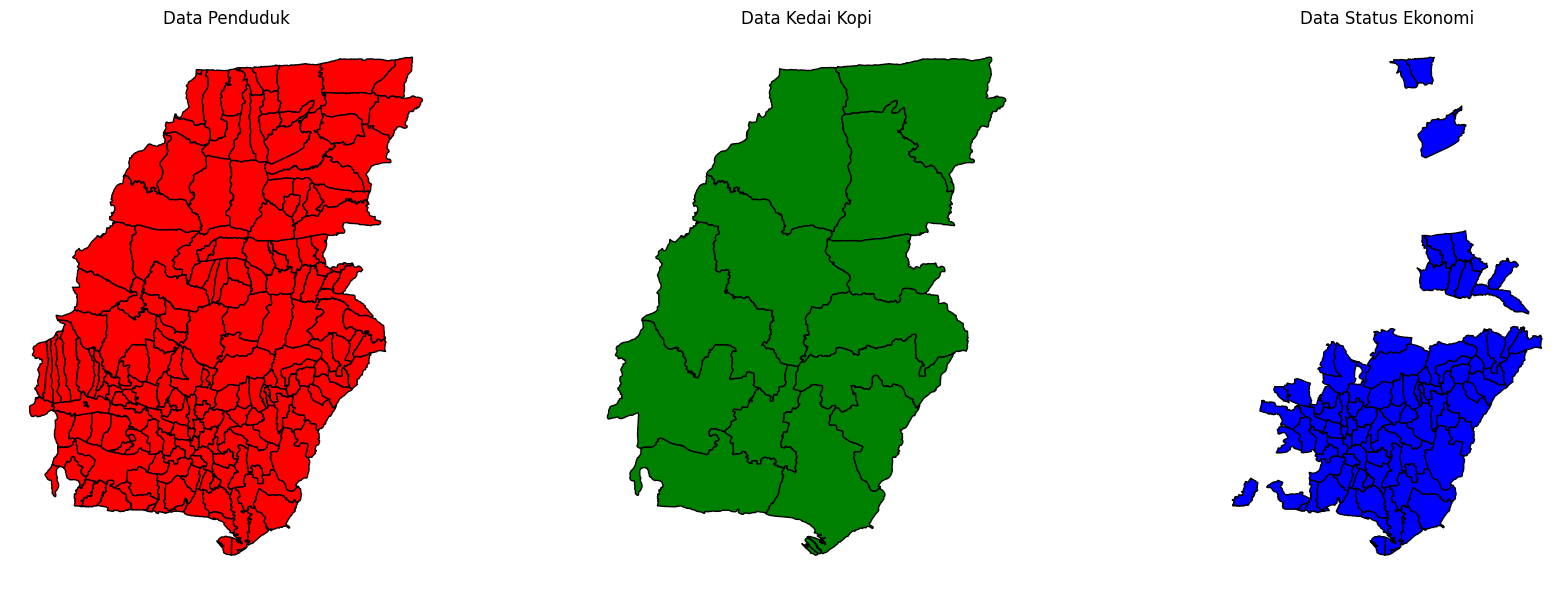

In [ ]:
#URL API
urls={"Jumlah Kedai Kopi per Kecamatan":"https://geoserver.mapid.io/layers_new/get_layer?api_key=10b2e2781d0d48629e03d6b6d4eff098&layer_id=68ae8326278efb81183b4868&project_id=68ad26dc329a028a97ae7f94&limit=10000",
      "Jumlah Penduduk per Kecamatan": "https://geoserver.mapid.io/layers_new/get_layer?api_key=10b2e2781d0d48629e03d6b6d4eff098&layer_id=68ae8627f4c6b405edd806e4&project_id=68ad26dc329a028a97ae7f94&limit=10000",
      "Status Ekonomi Desa": "https://geoserver.mapid.io/layers_new/get_layer?api_key=10b2e2781d0d48629e03d6b6d4eff098&layer_id=68aebb65abcfc44262fb3cf6&project_id=68ad26dc329a028a97ae7f94&limit=10000"

}

#Fungsi untuk mengambil data dan menambahkan kolom skor
def get_data(url, layer_name):
    response=requests.get(url)
    if response.status_code==200:
        geojson_data=response.json()
        gdf=gpd.GeoDataFrame.from_features(geojson_data['features'])

        
        #Menambahkan kolom skor berdasarkan layer
        if layer_name=="Jumlah Kedai Kopi per Kecamatan":
            gdf["SKOR_KEDAI"]=gdf.get("KELAS", "").str.upper().map({"Rendah":1, "Sedang":2, "Tinggi":3}).fillna(0) #ganti NaN dengan 0
        elif layer_name=="Jumlah Penduduk per Kecamatan":
            gdf["SKOR_PENDUDUK"]=gdf.get("KELAS_PENDUDUK", "").str.upper().map({"Rendah":3, "Sedang":2, "Tinggi":1}).fillna(0) #ganti NaN dengan 0
        elif layer_name=="Status Ekonomi Desa":
            gdf["SKOR_EKONOMI"]=gdf.get("KELAS_EKONOMI", "").str.upper().map({"Sedang":2, "Tinggi":3}).fillna(0) #ganti NaN dengan 0

        return gdf
    return gpd.GeoDataFrame()

#Ambil data untuk semua layer
gdf_kedai = get_data(urls["Jumlah Kedai Kopi per Kecamatan"], "Jumlah Kedai Kopi per Kecamatan")
gdf_penduduk = get_data(urls["Jumlah Penduduk per Kecamatan"], "Jumlah Penduduk per Kecamatan")
gdf_ekonomi = get_data(urls["Status Ekonomi Desa"], "Status Ekonomi Desa")

#Visualisasi data
def visualize_data(gdfs):
    fig, axes=plt.subplots(1, len(gdfs), figsize=(18,6))
    color_map=['red','green','blue'] #warna berbeda untuk setiap layer
    for ax, (name, gdf), color in zip(axes, gdfs.items(), color_map):
        gdf.plot(ax=ax, color=color, edgecolor='black')
        ax.set_title(name)
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()

#Menampilkan visualisasi dari ketiga GeoDataFrame
visualize_data({"Data Penduduk": gdf_penduduk, "Data Kedai Kopi":gdf_kedai, "Data Status Ekonomi":gdf_ekonomi})

In [24]:
#Perbaikan untuk mengatasi nilai null

#Periksa dan perbaiki nilai null sebelum intersect
gdf_penduduk['SKOR_PENDUDUK'] = gdf_penduduk['SKOR_PENDUDUK'].fillna(0)
gdf_kedai['SKOR_KEDAI'] = gdf_kedai['SKOR_KEDAI'].fillna(0)
gdf_ekonomi['SKOR_EKONOMI']=gdf_ekonomi['SKOR_EKONOMI'].fillna(0)

for name, gdf in [('Penduduk', gdf_penduduk), ('Kedai', gdf_kedai), ('Ekonomi', gdf_ekonomi)]:
    print(f"{name} geometry types:", gdf.geometry.type.unique())

#Intersection - hanya area yang overlap di semua layer
intersection_gdf=gdf_penduduk
if not gdf_kedai.empty:
    intersection_gdf = gpd.overlay(intersection_gdf, gdf_kedai, how='intersection', keep_geom_type=False)
if not gdf_ekonomi.empty:
    intersection_gdf = gpd.overlay(intersection_gdf, gdf_ekonomi, how='intersection', keep_geom_type=False)

#Memperbaiki geometri yang tidak valid setelah intersection
intersection_gdf = intersection_gdf[intersection_gdf.is_valid]
#Menghapus geometri yang tidak valid
intersection_gdf['geometry'] = intersection_gdf['geometry'].apply(lambda x: x.make_valid() if not x.is_valid else x)

# Perbaiki nilai NULL setelah intersection
intersection_gdf['SKOR_PENDUDUK'] =intersection_gdf['SKOR_PENDUDUK'].fillna(0)
intersection_gdf['SKOR_KEDAI'] =intersection_gdf['SKOR_KEDAI'].fillna(0)
intersection_gdf['SKOR_EKONOMI'] =intersection_gdf['SKOR_EKONOMI'].fillna(0)

# Hitung ulang skor total
intersection_gdf['SKOR_TOTAL'] = intersection_gdf['SKOR_PENDUDUK'] + intersection_gdf['SKOR_KEDAI'] + intersection_gdf['SKOR_EKONOMI']

# Klasifikasi
intersection_gdf['KESESUAIAN']= pd.cut(
    intersection_gdf['SKOR_TOTAL'],
    bins=[2, 5, 7, 9], # Rentang/Interval Skor
    labels=['Rendah', 'Sedang', 'Tinggi'],
    include_lowest=True
)

print(intersection_gdf[['SKOR_PENDUDUK', 'SKOR_KEDAI', 'SKOR_EKONOMI', 'SKOR_TOTAL', 'KESESUAIAN']].head(10))

Penduduk geometry types: ['Polygon']
Kedai geometry types: ['Polygon']
Ekonomi geometry types: ['Polygon']
   SKOR_PENDUDUK  SKOR_KEDAI  SKOR_EKONOMI  SKOR_TOTAL KESESUAIAN
0            0.0         0.0           0.0         0.0        NaN
1            0.0         0.0           0.0         0.0        NaN
2            0.0         0.0           0.0         0.0        NaN
3            0.0         0.0           0.0         0.0        NaN
4            0.0         0.0           0.0         0.0        NaN
5            0.0         0.0           0.0         0.0        NaN
6            0.0         0.0           0.0         0.0        NaN
7            0.0         0.0           0.0         0.0        NaN
8            0.0         0.0           0.0         0.0        NaN
9            0.0         0.0           0.0         0.0        NaN
